In [24]:
import platform
print(platform.machine())

armv7l


In [18]:
import numpy as np
import time

# -----------------------------
# 1. Load data from CSV manually
# -----------------------------
# Standard digits dataset has 64 features + 1 label at the end
# We use 'digits' as the filename based on your screenshot
raw_data = np.genfromtxt('digits.csv', delimiter=',')

X = raw_data[:, :-1] / 16.0  # Features (64 pixels)
y = raw_data[:, -1]          # Target (the digit 0-9)

# Binary classification (0 vs not 0)
y_binary = (y == 0).astype(int)

# Manual Train/Test Split (80/20)
indices = np.arange(X.shape[0])
np.random.seed(42)
np.random.shuffle(indices)
split = int(0.8 * len(indices))

train_idx, test_idx = indices[:split], indices[split:]
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y_binary[train_idx], y_binary[test_idx]

# Add bias (column of ones)
X_train = np.c_[np.ones(X_train.shape[0]), X_train]
X_test = np.c_[np.ones(X_test.shape[0]), X_test]

print(f"Dataset ready! Training samples: {len(X_train)}, Test samples: {len(X_test)}")

# -----------------------------
# Now you can run your Regression, KNN, and NN code below this!
# -----------------------------

Dataset ready! Training samples: 1437, Test samples: 360


In [20]:
import numpy as np
import time

# Ensure y_train is a column vector for matrix math
y_train_vec = y_train.reshape(-1, 1)
y_test_vec = y_test.reshape(-1, 1)

def sigmoid(z):
    # Clip z to prevent "overflow" errors in exp
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

results = []

# -----------------------------
# 1. Linear Regression
# -----------------------------
start = time.time()
# Normal Equation
theta = np.linalg.pinv(X_train.T @ X_train) @ X_train.T @ y_train_vec
train_time = time.time() - start

start_pred = time.time()
y_pred = np.round(X_test @ theta)
pred_time = time.time() - start_pred

acc = np.mean(y_pred == y_test_vec)
results.append(("Linear Regression", train_time, pred_time, acc))

# -----------------------------
# 2. Logistic Regression
# -----------------------------
theta_log = np.zeros((X_train.shape[1], 1))
lr = 0.1

start = time.time()
for _ in range(200):
    h = sigmoid(X_train @ theta_log)
    gradient = X_train.T @ (h - y_train_vec) / len(y_train_vec)
    theta_log -= lr * gradient
train_time = time.time() - start

start_pred = time.time()
y_pred = (sigmoid(X_test @ theta_log) >= 0.5).astype(int)
pred_time = time.time() - start_pred

acc = np.mean(y_pred == y_test_vec)
results.append(("Logistic Regression", train_time, pred_time, acc))

# -----------------------------
# 3. KNN
# -----------------------------
def knn_predict(X_tr, y_tr, X_te, k=3):
    preds = []
    for x in X_te:
        # Distance calculation is vectorized for speed
        distances = np.linalg.norm(X_tr - x, axis=1)
        idx = np.argsort(distances)[:k]
        vals = y_tr[idx]
        preds.append(np.round(np.mean(vals)))
    return np.array(preds).reshape(-1, 1)

start_pred = time.time()
y_pred = knn_predict(X_train, y_train, X_test)
pred_time = time.time() - start_pred

acc = np.mean(y_pred == y_test_vec)
results.append(("KNN", 0.0, pred_time, acc))

# -----------------------------
# 4. SVM (Stochastic Gradient Descent)
# -----------------------------
theta_svm = np.zeros((X_train.shape[1], 1))
lr = 0.01
lambda_param = 0.01
y_svm = np.where(y_train_vec == 1, 1, -1)

start = time.time()
for _ in range(50): # Reduced iterations for speed on ARM
    for i, x in enumerate(X_train):
        x = x.reshape(1, -1)
        condition = y_svm[i] * (x @ theta_svm) >= 1
        if condition:
            theta_svm -= lr * (2 * lambda_param * theta_svm)
        else:
            theta_svm -= lr * (2 * lambda_param * theta_svm - y_svm[i] * x.T)
train_time = time.time() - start

start_pred = time.time()
y_pred = np.sign(X_test @ theta_svm)
y_pred = (y_pred > 0).astype(int)
pred_time = time.time() - start_pred

acc = np.mean(y_pred == y_test_vec)
results.append(("SVM", train_time, pred_time, acc))

# -----------------------------
# 5. Neural Network (1 layer)
# -----------------------------
input_size = X_train.shape[1]
hidden_size = 32
W1 = np.random.randn(input_size, hidden_size) * 0.01
W2 = np.random.randn(hidden_size, 1) * 0.01
lr = 0.01

start = time.time()
for _ in range(200):
    # Forward
    z1 = X_train @ W1
    a1 = np.tanh(z1)
    z2 = a1 @ W2
    a2 = sigmoid(z2)

    # Backprop
    dz2 = a2 - y_train_vec
    dW2 = a1.T @ dz2
    dz1 = (dz2 @ W2.T) * (1 - np.tanh(z1)**2)
    dW1 = X_train.T @ dz1

    W1 -= lr * dW1
    W2 -= lr * dW2
train_time = time.time() - start

start_pred = time.time()
z1 = X_test @ W1
a1 = np.tanh(z1)
y_pred = (sigmoid(a1 @ W2) > 0.5).astype(int)
pred_time = time.time() - start_pred

acc = np.mean(y_pred == y_test_vec)
results.append(("Neural Network", train_time, pred_time, acc))

# -----------------------------
# Final Output
# -----------------------------
print("-" * 65)
print(f"{'Model':<20} | {'Train (s)':<10} | {'Inference (s)':<12} | {'Acc'}")
print("-" * 65)
for name, t_time, p_time, accuracy in results:
    print(f"{name:<20} | {t_time:<10.4f} | {p_time:<12.4f} | {accuracy:.4f}")

-----------------------------------------------------------------
Model                | Train (s)  | Inference (s) | Acc
-----------------------------------------------------------------
Linear Regression    | 0.2814     | 0.0016       | 0.9944
Logistic Regression  | 0.7479     | 0.0022       | 0.9750
KNN                  | 0.0000     | 4.9873       | 1.0000
SVM                  | 16.4419    | 0.0021       | 0.9944
Neural Network       | 24.1654    | 0.0170       | 0.8778


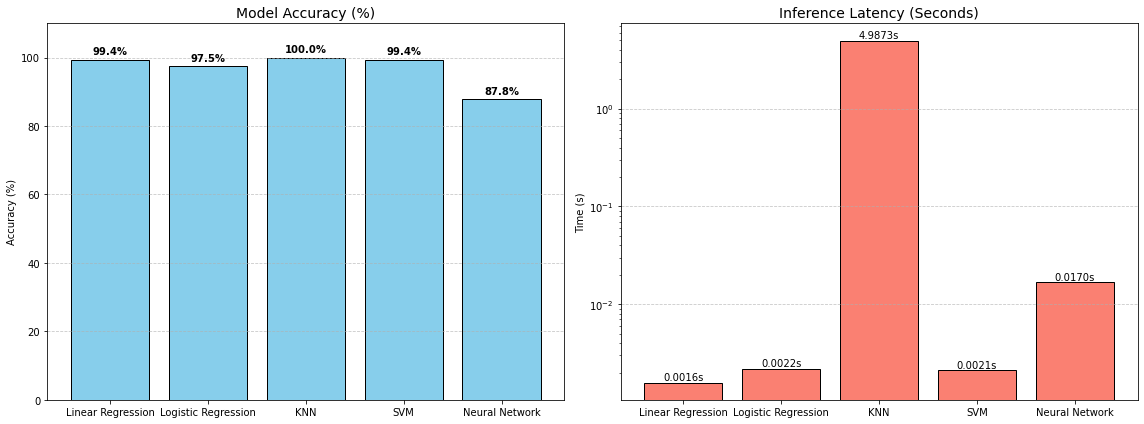

In [22]:
import matplotlib.pyplot as plt

# Extract data from your results list
names = [r[0] for r in results]
train_times = [r[1] for r in results]
inf_times = [r[2] for r in results]
accuracies = [r[3] for r in results]

# Create the figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Accuracy (Percentage)
bars1 = ax1.bar(names, [a * 100 for a in accuracies], color='skyblue', edgecolor='black')
ax1.set_title('Model Accuracy (%)', fontsize=14)
ax1.set_ylabel('Accuracy (%)')
ax1.set_ylim(0, 110)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Add text labels on top of bars
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

# Plot 2: Inference Latency (Log Scale recommended because KNN is so much slower)
bars2 = ax2.bar(names, inf_times, color='salmon', edgecolor='black')
ax2.set_title('Inference Latency (Seconds)', fontsize=14)
ax2.set_ylabel('Time (s)')
ax2.set_yscale('log')  # Using log scale to see the fast models clearly next to KNN
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Add text labels for timing
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}s', ha='center', va='bottom')

plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'finn_examples'